## Kriteria 2: Melakukan Seluruh Proses Analisis Data
Mirip seperti berbagai materi latihan yang telah dibahas sebelumnya, Anda harus melakukan seluruh proses analisis <br>
data mulai dari mendefinisikan pertanyaan hingga membuat kesimpulan dari hasil analisis. Selain itu, proyek analisis data yang Anda buat harus memenuhi ketentuan berikut.

Minimal terdapat 2 buah pertanyaan bisnis (pertanyaan analisis) yang ingin dijawab melalui proses analisis data. Pertanyaan tersebut haruslah efektif sesuai dengan materi Mendefinisikan Pertanyaan Untuk Explorasi Data.
Minimal terdapat 2 buah visualisasi data untuk menjawab pertanyaan bisnis yang telah dibuat.

## Kriteria 3: Proses Analisis Dibuat dalam Notebook yang Rapi
Pada submission ini, Anda harus mengerjakan proyek analisis data menggunakan templat proyek yang telah disediakan. Tujuannya supaya proyek yang dibuat terdokumentasi dengan rapi. Templat yang dimaksud dapat diakses pada tautan berikut: templat notebook.

## Kriteria 4: Membuat Dashboard Sederhana Menggunakan Streamlit
Setelah melakukan proses analisis, selanjutnya Anda wajib membuat dashboard sebagai media untuk menyampaikan hasil analisis data secara interaktif. Pada proyek ini, Anda dapat membuat dashboard dengan streamlit mirip seperti materi latihan sebelumnya. Selain itu, pastikan bahwa dashboard Anda buat dapat berjalan dengan lancar di local.



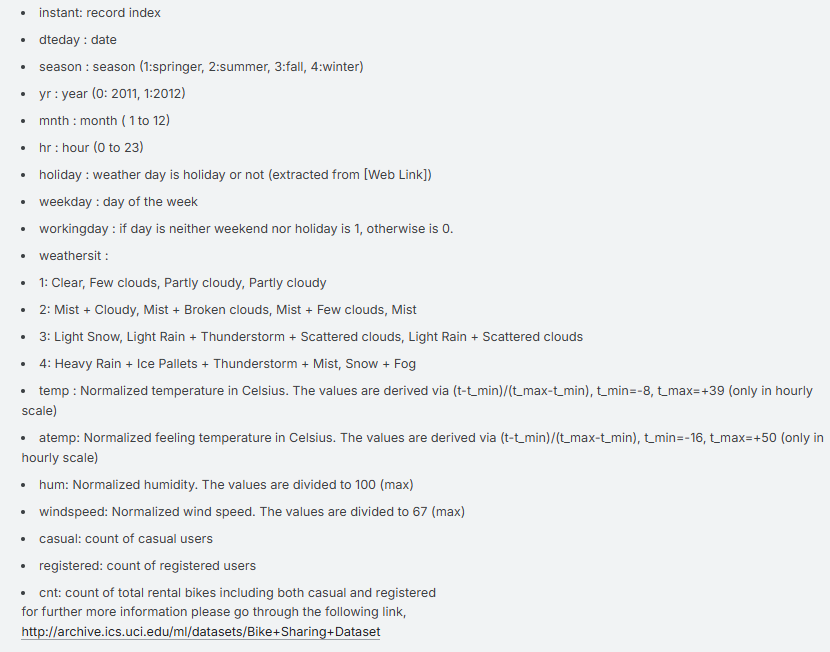
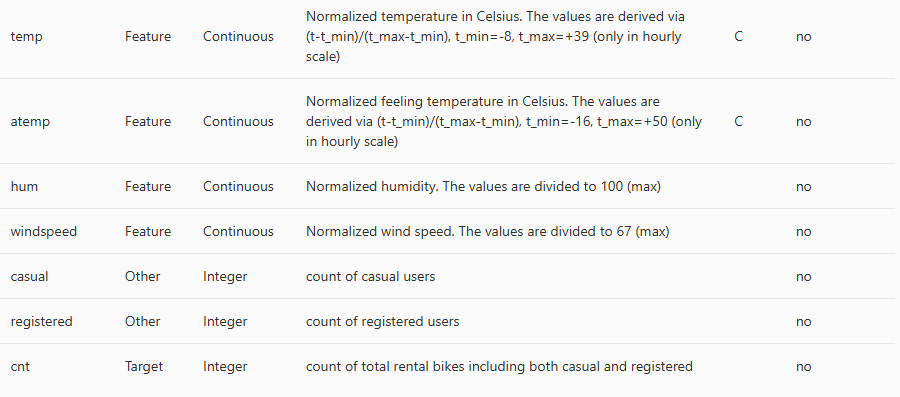
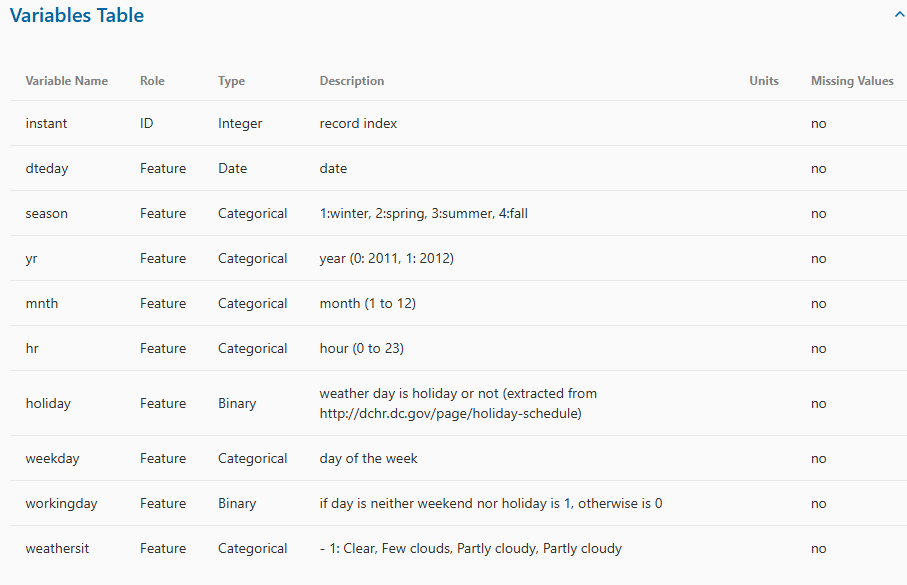

## Kriteria 2: Seluruh Proses Analisis Data
### Pertanyaan Bisnis

1. Bagaimana perbedaan rata-rata jumlah peminjaman sepeda harian pada setiap kondisi cuaca selama periode pengamatan dataset?

2. Bagaimana perbedaan rata-rata jumlah peminjaman sepeda harian antara hari kerja dan akhir pekan di periode tertentu?


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [26]:
df = pd.read_csv('data/day.csv')

df.head(10)

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,6,0,2,0.344167,0.363625,0.805833,0.160446,331,654,985
1,2,2011-01-02,1,0,1,0,0,0,2,0.363478,0.353739,0.696087,0.248539,131,670,801
2,3,2011-01-03,1,0,1,0,1,1,1,0.196364,0.189405,0.437273,0.248309,120,1229,1349
3,4,2011-01-04,1,0,1,0,2,1,1,0.200000,0.212122,0.590435,0.160296,108,1454,1562
4,5,2011-01-05,1,0,1,0,3,1,1,0.226957,0.229270,0.436957,0.186900,82,1518,1600
5,6,2011-01-06,1,0,1,0,4,1,1,0.204348,0.233209,0.518261,0.089565,88,1518,1606
6,7,2011-01-07,1,0,1,0,5,1,2,0.196522,0.208839,0.498696,0.168726,148,1362,1510
7,8,2011-01-08,1,0,1,0,6,0,2,0.165000,0.162254,0.535833,0.266804,68,891,959
8,9,2011-01-09,1,0,1,0,0,0,1,0.138333,0.116175,0.434167,0.361950,54,768,822
9,10,2011-01-10,1,0,1,0,1,1,1,0.150833,0.150888,0.482917,0.223267,41,1280,1321


In [22]:
df['weathersit'].unique()


array([2, 1, 3])

In [ ]:
sns.set_theme(
    style="whitegrid",
    context="talk",
    rc={
        "grid.linestyle": "--",
        "grid.alpha": 0.6,
        "axes.edgecolor": "#333333",
        "axes.linewidth": 1
    }
)

weather_map = {
    1: "Clear",
    2: "Mist+Cloudy",
    3: "Light Rain",
    4: "Heavy Rain"
}
df["weather"] = df["weathersit"].map(weather_map)

df["day_type"] = df.apply(
    lambda r: "Working day" if r["workingday"] == 1 else "Weekend/Holiday",
    axis=1
)

weather_order = ["Clear/Partly Cloudy", "Mist/Cloudy", "Light Rain/Snow", "Heavy Rain/Snow"]
daytype_order = ["Weekend/Holiday", "Working day"]


# 1. Bagaimana perbedaan rata-rata jumlah peminjaman sepeda harian pada setiap kondisi cuaca selama periode pengamatan dataset?


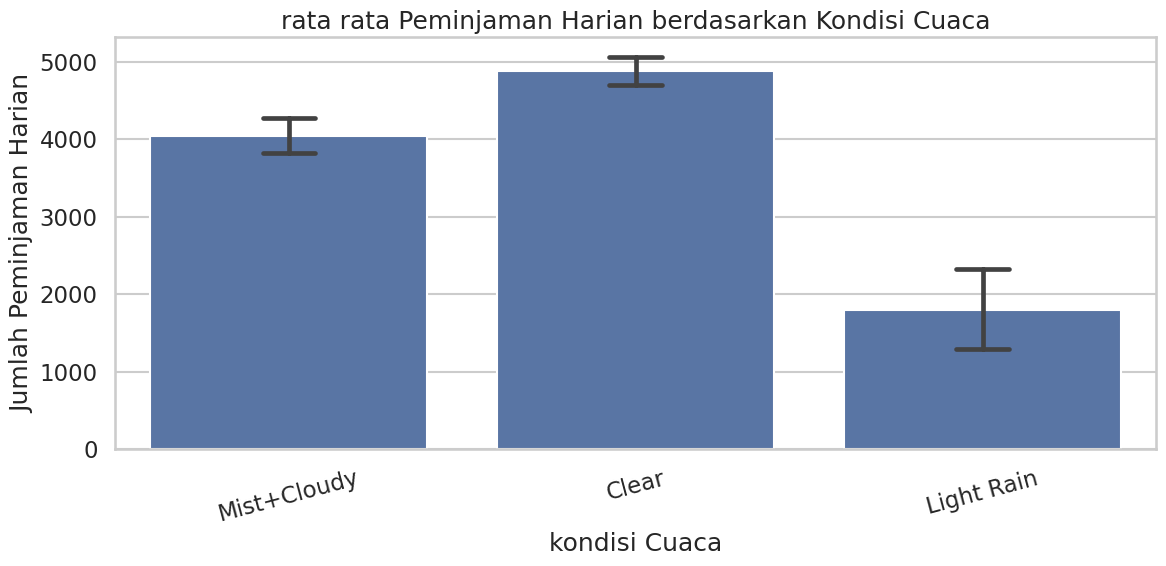

In [29]:
fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(
    data=df,
    x="weather",
    y="cnt",
    estimator="mean",
    errorbar=("ci", 95),
    capsize=0.15,
    ax=ax
)
ax.set_title("rata rata Peminjaman Harian berdasarkan Kondisi Cuaca")
ax.set_xlabel("kondisi Cuaca")
ax.set_ylabel("Jumlah Peminjaman Harian")
ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()


> Berdasarkan visualisasi, rata-rata peminjaman sepeda harian paling tinggi terjadi pada kondisi cuaca cerah.<br>
> Pada kondisi berkabut atau berawan, jumlah peminjaman sedikit menurun namun masih relatif tinggi.<br>
> Sementara itu, pada kondisi hujan ringan, rata-rata peminjaman sepeda mengalami penurunan paling signifikan.<br>
> Hal ini menunjukkan bahwa kondisi cuaca berpengaruh terhadap intensitas penggunaan sepeda.<br>

asumsi saya mungkin karena gerimis orang males naik sepeda:)

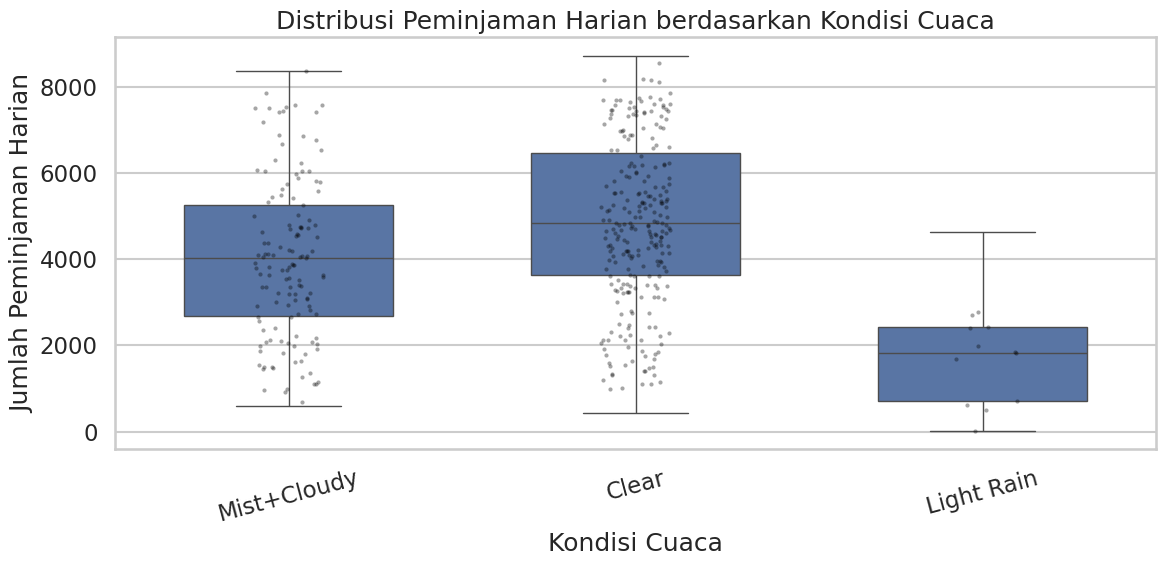

In [37]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.boxplot(
    data=df,
    x="weather",
    y="cnt",
    showfliers=False,
    width=0.6,
    ax=ax
)

sns.stripplot(
    data=df.sample(min(len(df), 400), random_state=42),
    x="weather",
    y="cnt",
    color="black",
    size=3,
    alpha=0.35,
    ax=ax
)

ax.set_title("Distribusi Peminjaman Harian berdasarkan Kondisi Cuaca")
ax.set_xlabel("Kondisi Cuaca")
ax.set_ylabel("Jumlah Peminjaman Harian")
ax.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.show()


>Pada kondisi berkabut atau berawan, rata-rata peminjaman berada pada tingkat menengah, sedangkan pada kondisi hujan ringan rata-rata peminjaman sepeda paling rendah.<br>
Hal ini menunjukkan bahwa semakin buruk kondisi cuaca, semakin rendah rata-rata jumlah peminjaman sepeda harian.

# 2. Bagaimana perbedaan rata-rata jumlah peminjaman sepeda harian antara hari kerja dan akhir pekan di periode tertentu?


In [32]:
df["day_type"] = "Weekend"
df.loc[df["workingday"] == 1, "day_type"] = "Working Day"
df.loc[df["holiday"] == 1, "day_type"] = "Holiday"


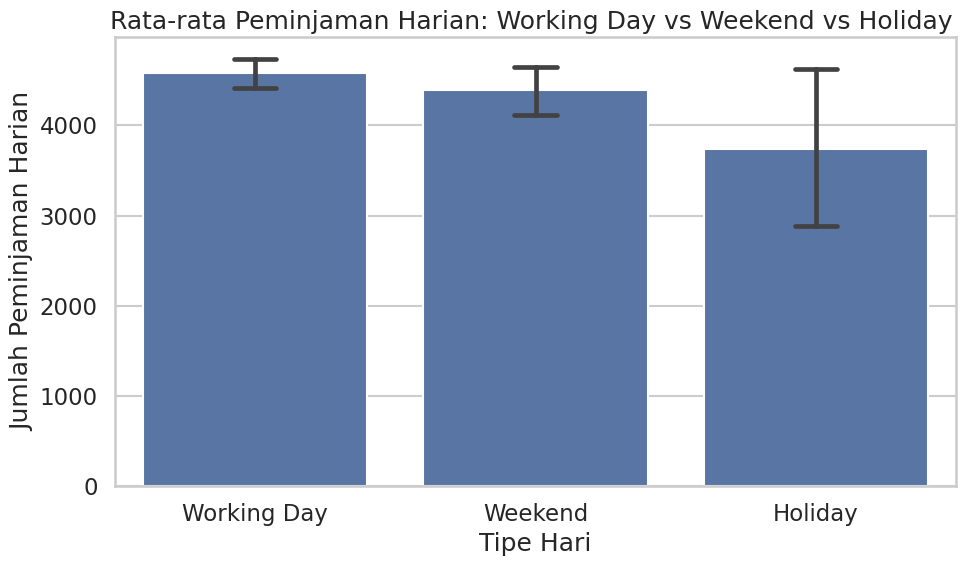

In [34]:
order = ["Working Day", "Weekend", "Holiday"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(
    data=df,
    x="day_type",
    y="cnt",
    order=order,
    estimator="mean",
    errorbar=("ci", 95),
    capsize=0.15,
    ax=ax
)
ax.set_title("Rata-rata Peminjaman Harian: Working Day vs Weekend vs Holiday ")
ax.set_xlabel("Tipe Hari")
ax.set_ylabel("Jumlah Peminjaman Harian")
plt.tight_layout()
plt.show()


>Berdasarkan visualisasi rata-rata peminjaman harian , hari kerja atau Working Day memiliki rata-rata peminjaman tertinggi, diikuti oleh akhir pekan atau Weekend, sedangkan hari libur atau Holiday menunjukkan rata-rata terendah. <br>
>Perbedaan ini mengindikasikan bahwa peminjaman sepeda pada hari kerja cenderung didorong oleh aktivitas rutin seperti bekerja atau sekolah, sementara pada akhir pekan sedikit lebih rendah dan pada hari libur paling rendah.<br>

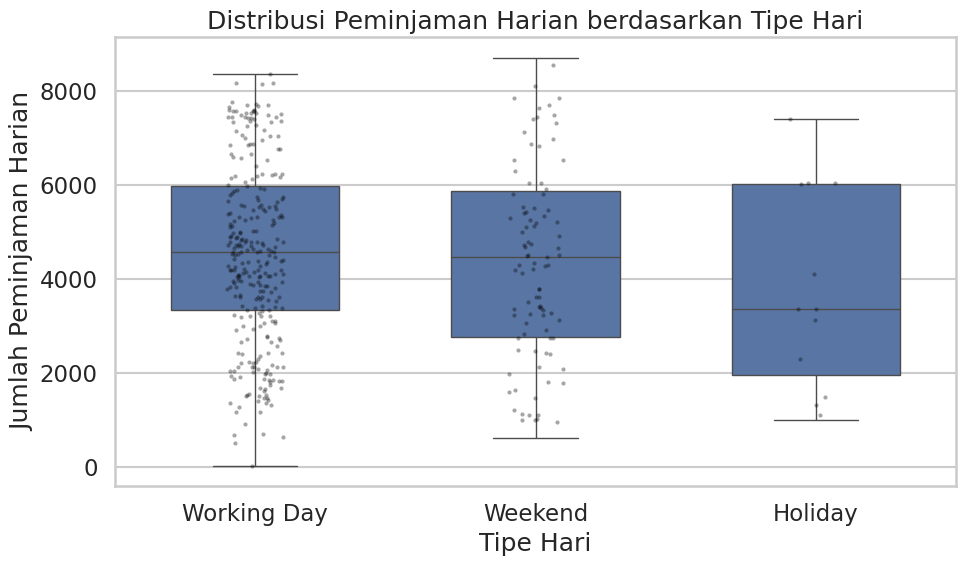

In [36]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.boxplot(
    data=df,
    x="day_type",
    y="cnt",
    order=order,
    showfliers=False,
    width=0.6,
    ax=ax
)

sns.stripplot(
    data=df.sample(min(len(df), 400), random_state=42),
    x="day_type",
    y="cnt",
    order=order,
    color="black",
    size=3,
    alpha=0.35,
    ax=ax
)

ax.set_title("Distribusi Peminjaman Harian berdasarkan Tipe Hari")
ax.set_xlabel("Tipe Hari")
ax.set_ylabel("Jumlah Peminjaman Harian")

plt.tight_layout()
plt.show()


Berdasarkan visualisasi distribusi peminjaman harian, hari kerja (Working Day) menunjukkan nilai tengah (median) peminjaman yang relatif lebih tinggi dan lebih stabil dibandingkan tipe hari lainnya.
Pada akhir pekan (Weekend), distribusi peminjaman masih berada pada tingkat yang cukup tinggi, namun variasinya lebih besar, menandakan perbedaan penggunaan sepeda antar hari.
Sementara itu, hari libur (Holiday) memiliki nilai tengah peminjaman yang lebih rendah dengan sebaran yang lebih lebar, menunjukkan bahwa peminjaman sepeda pada hari libur cenderung lebih rendah dan tidak konsisten.